In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns

# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")

DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)


# Cluster Analysis

To conduct a clustering of the registered users, we first need to extract all session with a registered user and store these instances in a new variable

In [2]:
registered_users_df = merged_df[merged_df['isRegisteredUser'] == True].copy()

In [3]:
print(f"Total sessions in merged_df: {len(merged_df)}")
print(f"Sessions from registered users: {len(registered_users_df)}")
print(f"Unique registered users to cluster: {registered_users_df['userID'].nunique()}")

Total sessions in merged_df: 65006
Sessions from registered users: 47815
Unique registered users to cluster: 1006


In [4]:
registered_users_df['siteID'].dtype
registered_users_df['siteID_numeric'] = (registered_users_df['siteID'] == '1').astype(int)

In [5]:
registered_users_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47815 entries, 2 to 65005
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   id                  47815 non-null  object                             
 1   connectionTime      47815 non-null  datetime64[ns, America/Los_Angeles]
 2   disconnectTime      47815 non-null  datetime64[ns, America/Los_Angeles]
 3   doneChargingTime    47815 non-null  datetime64[ns, America/Los_Angeles]
 4   kWhDelivered        47815 non-null  float64                            
 5   sessionID           47815 non-null  object                             
 6   siteID              47815 non-null  object                             
 7   spaceID             47815 non-null  object                             
 8   stationID           47815 non-null  object                             
 9   userID              47815 non-null  object  

In [6]:
# Aggregating statisitcs to User Level
user_profiles = registered_users_df.groupby('userID').agg(
    avg_energy=('kWhDelivered', 'mean'),
    std_energy=('kWhDelivered', 'std'),
    total_energy=('kWhDelivered', 'sum'),
    avg_kWh_req=('kWhRequested', 'mean'),
    frequency=('sessionID', 'count'),
    avg_duration=('session_duration', 'mean'),
    total_charging_duration=('charging_duration', 'sum'),
    avg_charging_duration=('charging_duration', 'mean'), 
    avg_start_hour=('hour', 'mean'),
    pct_weekend_sessions=('is_weekend', 'mean'),
    avg_minutes_available=('minutesAvailable', 'mean'),
    pct_site_1=('siteID_numeric', 'mean')
)

user_profiles['avg_energy_per_session'] = user_profiles['total_energy'] / user_profiles['frequency']
user_profiles['avg_charging_speed'] = user_profiles['total_energy'] / (user_profiles['total_charging_duration'] / 60)



In [7]:
user_profiles.head()

,avg_energy,std_energy,total_energy,avg_kWh_req,frequency,avg_duration,total_charging_duration,avg_charging_duration,avg_start_hour,pct_weekend_sessions,avg_minutes_available,pct_site_1,avg_energy_per_session,avg_charging_speed
userID,,,,,,,,,,,,,,
1.0,1.659000,NaN,1.659000,5.000000,1,1.404444,1.241111,1.241111,13.000000,0.0,150.000000,0.0,1.659000,80.202328
17.0,1.471000,NaN,1.471000,13.840000,1,0.302222,0.300278,0.300278,15.000000,1.0,72.000000,0.0,1.471000,293.927845
22.0,18.754998,8.609281,1087.789899,36.906034,58,6.354296,245.049722,4.224995,9.396552,0.0,462.034483,0.0,18.754998,266.343472
43.0,43.266000,NaN,43.266000,43.400000,1,8.282222,6.988333,6.988333,9.000000,1.0,469.000000,0.0,43.266000,371.470546
45.0,8.069000,NaN,8.069000,17.500000,1,3.551389,2.157500,2.157500,17.000000,1.0,134.000000,0.0,8.069000,224.398610


In [8]:
# use a indicator fo user with only one session & fill std_energy NaN with median
user_profiles['single_session_user'] = (user_profiles['frequency'] == 1).astype(int)
std_median = user_profiles['std_energy'].median(skipna=True)
user_profiles['std_energy_filled'] = user_profiles['std_energy'].fillna(std_median)

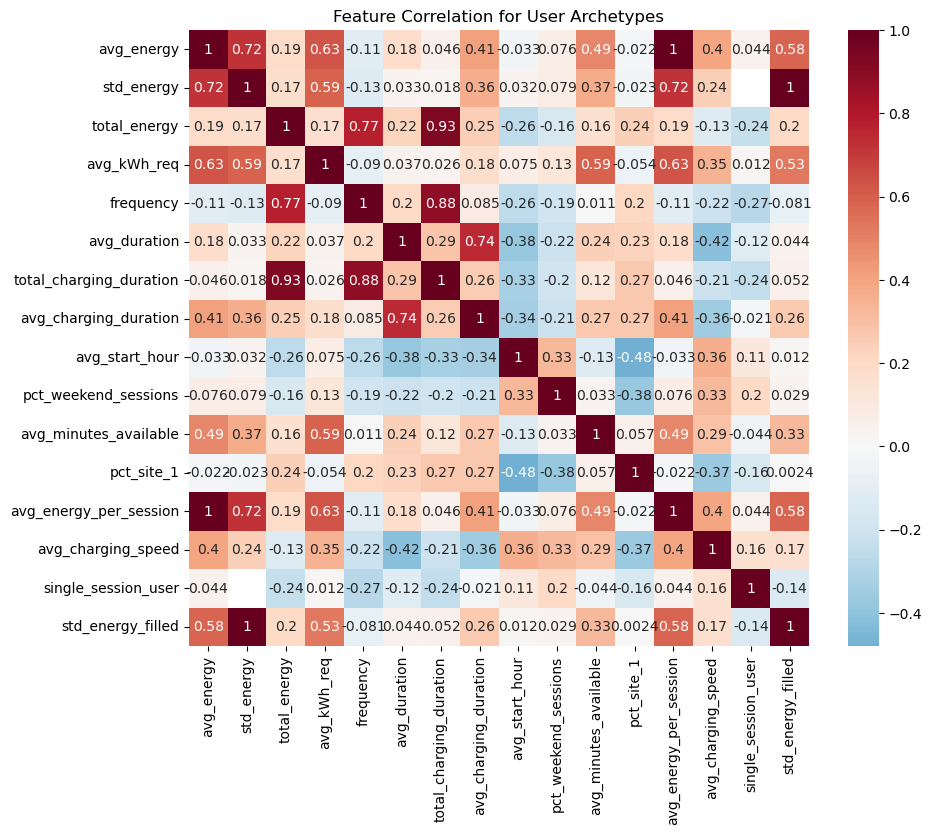

In [9]:
corr_matrix = user_profiles.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation for User Archetypes')
plt.show()

We use a correlation matrix to identify redundant features before clustering. If two features are highly correlated —such as `avg_session_duration` and `avg_charging_duration` (0.74)— including both would effectively double their weight in the distance calculation, biasing the clusters.

The matrix also reveals unexpected relationships between variables. For instance, while we would intuitively expect a strong positive correlation between `avg_duration` and `avg_energy`, they show a surprisingly low correlation of only 0.18. This suggests that stay time is not a reliable predictor of energy delivered, indicating distinct user behaviors, which we will explore further in the following analysis.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

features_to_standardize = ['std_energy_filled',
    'frequency','avg_duration',
     'avg_start_hour',
      'avg_charging_speed']
features_to_passthrough = [] # if we want to include features such as 'pct_site_1' without scaling
cluster_features = features_to_standardize + features_to_passthrough

ct = ColumnTransformer([
    ('scaled_features', StandardScaler(), features_to_standardize),
    ('passthrough_features', 'passthrough', features_to_passthrough)
])

user_profiles_scaled_array = ct.fit_transform(user_profiles)

user_profiles_scaled = pd.DataFrame(
    user_profiles_scaled_array,
    columns=cluster_features,
    index=user_profiles.index
)

We chose to limit the clustering analysis on fewer features for the following reasons:
* Including more features led to overlap between groups, making it difficult to identify distinct clusters.
* The resulting archetypes are easier to define and understand.

We chose `avg_duration` and `avg_energy` because despite the expectation that energy consumption would increase with session duration, these features showed a low correlation of only 0.18. This low correlation indicates the existence of two very different behaviors: users who treat the station primarily for parking (high duration, low energy) and those who use it for efficient charging (high energy, relatively lower duration). Our aim is to confirm these groups through clustering.

We choose the following features to cover many different dimension which gives us better interpreting clusters.

* Energy and Demand
  * std_energy
* Frequency and duration of use
  * frequency
  * avg_duration
* Temporal Behavior
  * avg_start_hour
* Charging Behavior/ Efficiency
  * avg_charging_speed



In [11]:
print(user_profiles_scaled.shape)

(1006, 5)


In [ ]:

outliers = (np.abs(user_profiles_scaled[[ 'std_energy_filled',
    'frequency','avg_duration',
    'avg_start_hour',
    'avg_charging_speed']]) > 3).any(axis=1)
print(f"Anzahl der Nutzer mit mindestens einem extremen Feature (Z > 3): {outliers.sum()}")

Anzahl der Nutzer mit mindestens einem extremen Feature (Z > 3): 94


The features `std_energy`, `frequency`, `avg_duration`, `avg_start_hour` and`charging_speed`  contain outliers that could negatively impact the clustering process. To address this we, identify and remove outliers using the 1 sigma threshold, which has proven to improve the Silhouette Score later the best.

In [13]:
user_profiles_scaled = user_profiles_scaled[~outliers].copy()
user_profiles = user_profiles[~outliers].copy()

### Hyperparameter Tuning

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory l

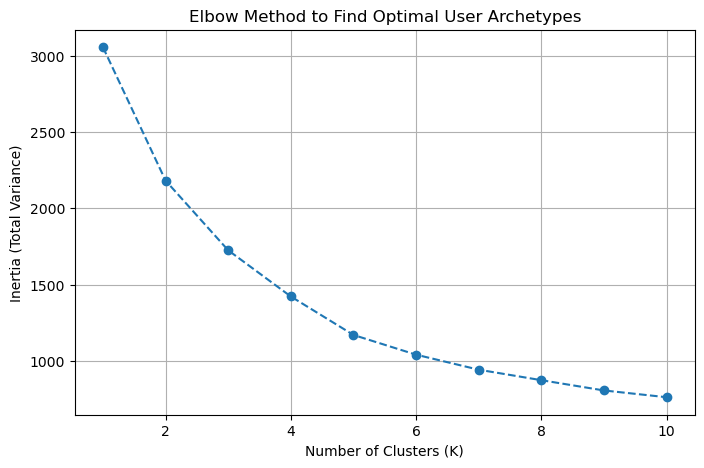

In [14]:
from sklearn.cluster import KMeans

# Calculate inertia for K=1 to K=10
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(user_profiles_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Total Variance)')
plt.title('Elbow Method to Find Optimal User Archetypes')
plt.grid(True)
plt.show()

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\clust

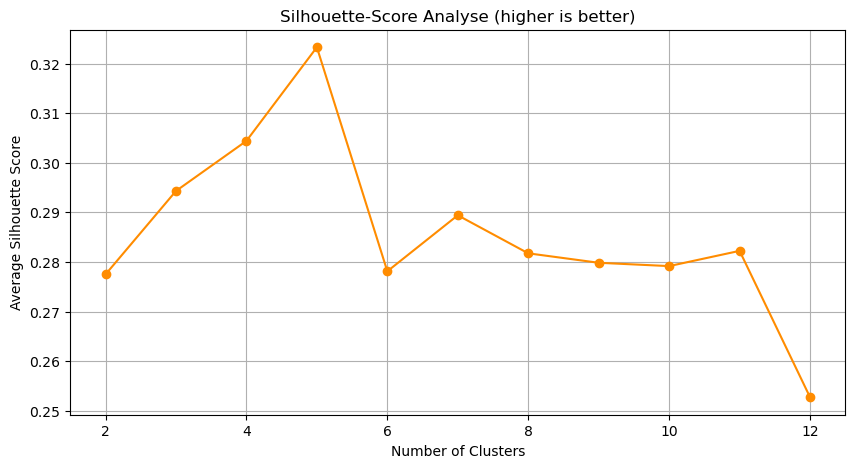

In [15]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
range_n_clusters = [2, 3, 4, 5, 6, 7, 8 ,9 ,10, 11, 12]
silhouette_avgs = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(user_profiles_scaled)
    
    silhouette_avg = silhouette_score(user_profiles_scaled, cluster_labels)
    silhouette_avgs.append(silhouette_avg)
    # print(f"Für n_clusters = {n_clusters} ist der durchschnittliche Silhouette-Score: {silhouette_avg:.3f}")

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_avgs, marker='o', color='darkorange')
plt.title('Silhouette-Score Analyse (higher is better)')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

We decided to use 5 clusters for our analysis because:
* The Silhouette analysis shows a clear peak at $k=5$ with a score of approximately 0.325. This indicates that five clusters provide the best balance between internal cohesion and separation between groups.
* In the Elbow plot, the "bend" or elbow occurs at $k=4 or k=5$. Adding a more cluster results in significantly diminishing returns in terms of reducing the Total Variance (Inertia), suggesting that four or five is the "sweet spot" for capturing the data's underlying structure.

* **with the Silhouette suggesting four and the elbow method four or five, we decide to use k=5**

### Cluster Alg implementation

In [16]:

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=8, 
    init='k-means++', 
    n_init=10, 
    random_state=42
)
kmeans.fit(user_profiles_scaled)

user_profiles['Clusters'] = kmeans.predict(user_profiles_scaled)


c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


#### I decided to choose KMeans, however this is GMM implementation.

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\clust

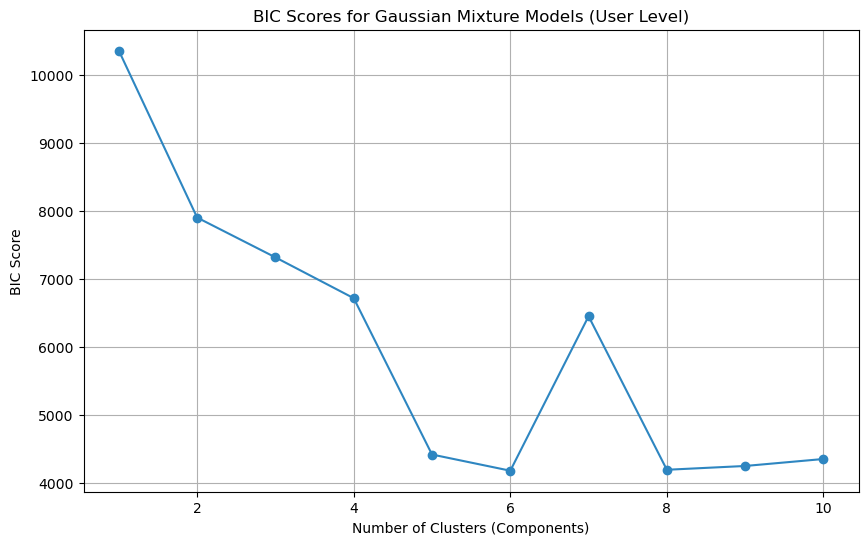

In [17]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 1. BIC-Score Berechnung zur Bestimmung der optimalen Cluster-Anzahl
bic_scores = []
n_components_range = range(1, 11)  # Bei 1000 Usern reichen oft 1-10 Komponenten

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(user_profiles_scaled)
    bic_scores.append(gmm.bic(user_profiles_scaled))

# Plot BIC
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, marker='o', color='#2E86C1')
plt.title('BIC Scores for Gaussian Mixture Models (User Level)')
plt.xlabel('Number of Clusters (Components)')
plt.ylabel('BIC Score')
plt.grid(True)
plt.show()

In [18]:
optimal_components = 5
best_gmm = GaussianMixture(n_components=optimal_components)
best_gmm.fit(user_profiles_scaled)
user_profiles['Clusters'] = best_gmm.predict(user_profiles_scaled)

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


### Clustering Results Analysis

In [19]:
cluster_mapping = {
    0: 'Cluster 1', 
    1: 'Cluster 2',
    2: 'Cluster 3',
    3: 'Cluster 4',
    4: 'Cluster 5'
   
    
}
user_profiles['Clusters_Name'] = user_profiles['Clusters'].map(cluster_mapping)

cluster_summary = user_profiles.groupby('Clusters_Name')[cluster_features].mean()

print("--- ARCHETYPEN REPORT (Mean per cluster) ---")

print(cluster_summary.T) 

print("\nNumber of users per archetype:")
counts = user_profiles['Clusters_Name'].value_counts()
print(counts)

--- ARCHETYPEN REPORT (Mean per cluster) ---
Clusters_Name        Cluster 1    Cluster 2   Cluster 3   Cluster 4  \
std_energy_filled     6.347400     6.658182    2.939235   10.236512   
frequency            93.374631    15.701754   10.815789   33.308411   
avg_duration          6.646409     1.010664    4.614015    6.088464   
avg_start_hour        9.237223    14.901366   11.395277   12.220914   
avg_charging_speed  218.477738  1299.863492  221.667194  309.858358   

Clusters_Name        Cluster 5  
std_energy_filled     4.244021  
frequency             1.000000  
avg_duration          4.246230  
avg_start_hour       11.699301  
avg_charging_speed  397.106962  

Number of users per archetype:
Clusters_Name
Cluster 1    339
Cluster 3    266
Cluster 5    143
Cluster 4    107
Cluster 2     57
Name: count, dtype: int64


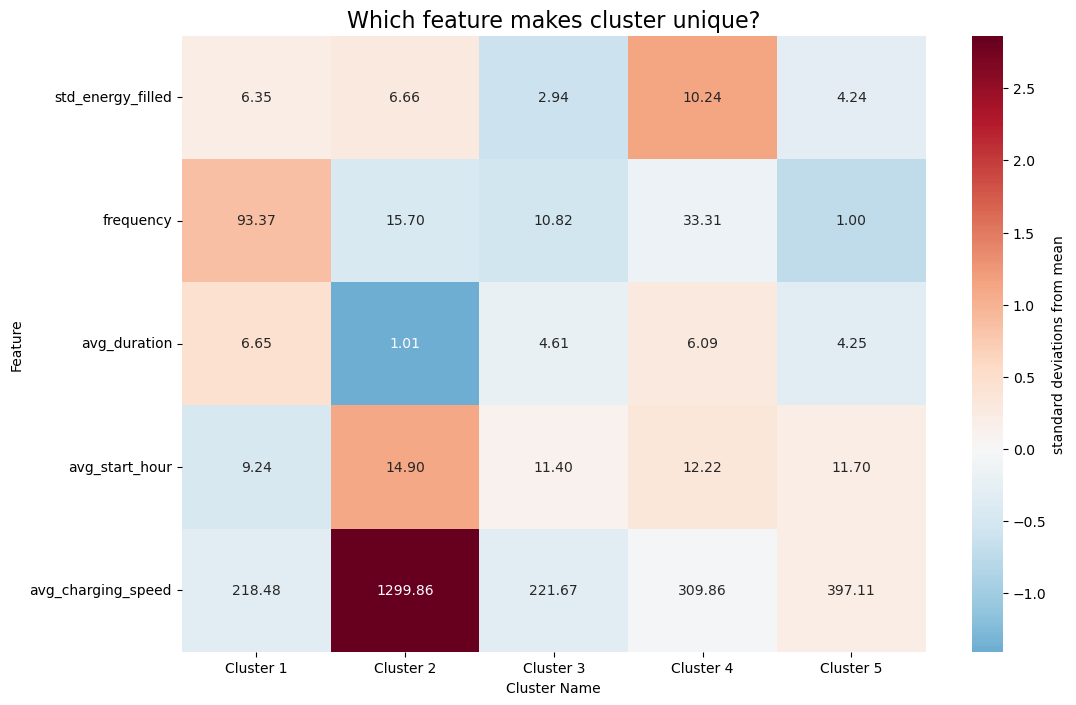

In [20]:
import seaborn as sns

cluster_summary = user_profiles.groupby('Clusters_Name')[cluster_features].mean()

# (Z-Score der Mittelwerte)
summary_scaled = (cluster_summary - user_profiles[cluster_features].mean()) / user_profiles[cluster_features].std()

plt.figure(figsize=(12, 8))
sns.heatmap(summary_scaled.T, 
            annot=cluster_summary.T,
            fmt=".2f", 
            cmap="RdBu_r", 
            center=0,
            cbar_kws={'label': 'standard deviations from mean'})

plt.title('Which feature makes cluster unique?', fontsize=16)
plt.xlabel('Cluster Name')
plt.ylabel('Feature')
plt.show()

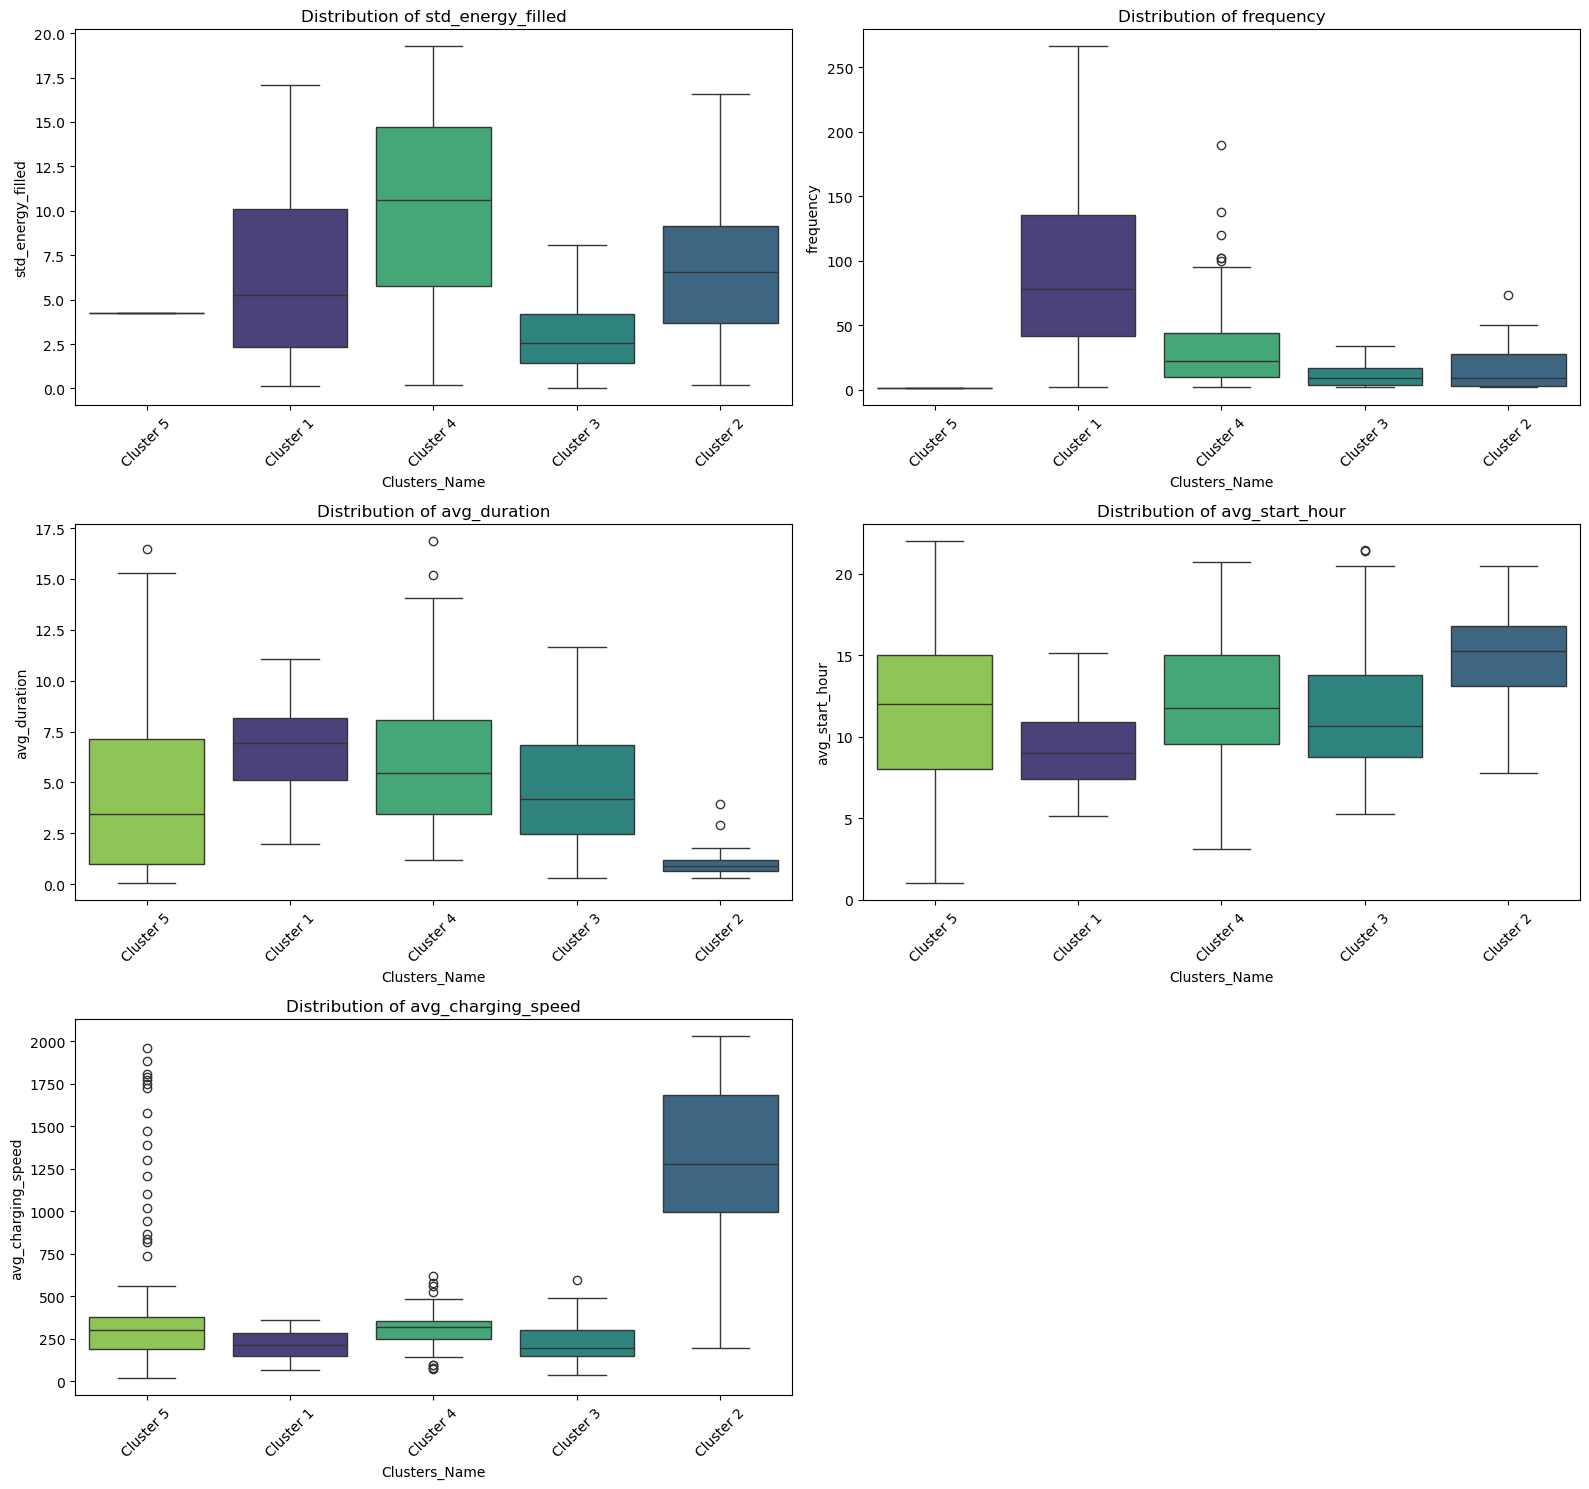

In [32]:
import math


num_features = len(cluster_features)
cols = 2
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

cluster_order = sorted(
    user_profiles['Clusters_Name'].unique(), 
    key=lambda s: int(s.split()[-1])
)

for i, feature in enumerate(cluster_features):
    sns.boxplot(
        x='Clusters_Name', 
        y=feature, 
        data=user_profiles, 
        ax=axes[i], 
        palette='viridis', 
        hue='Clusters_Name', 
        hue_order=cluster_order,
        legend=False
    )
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', labelrotation=45)

# Remove any empty subplots if num_features is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

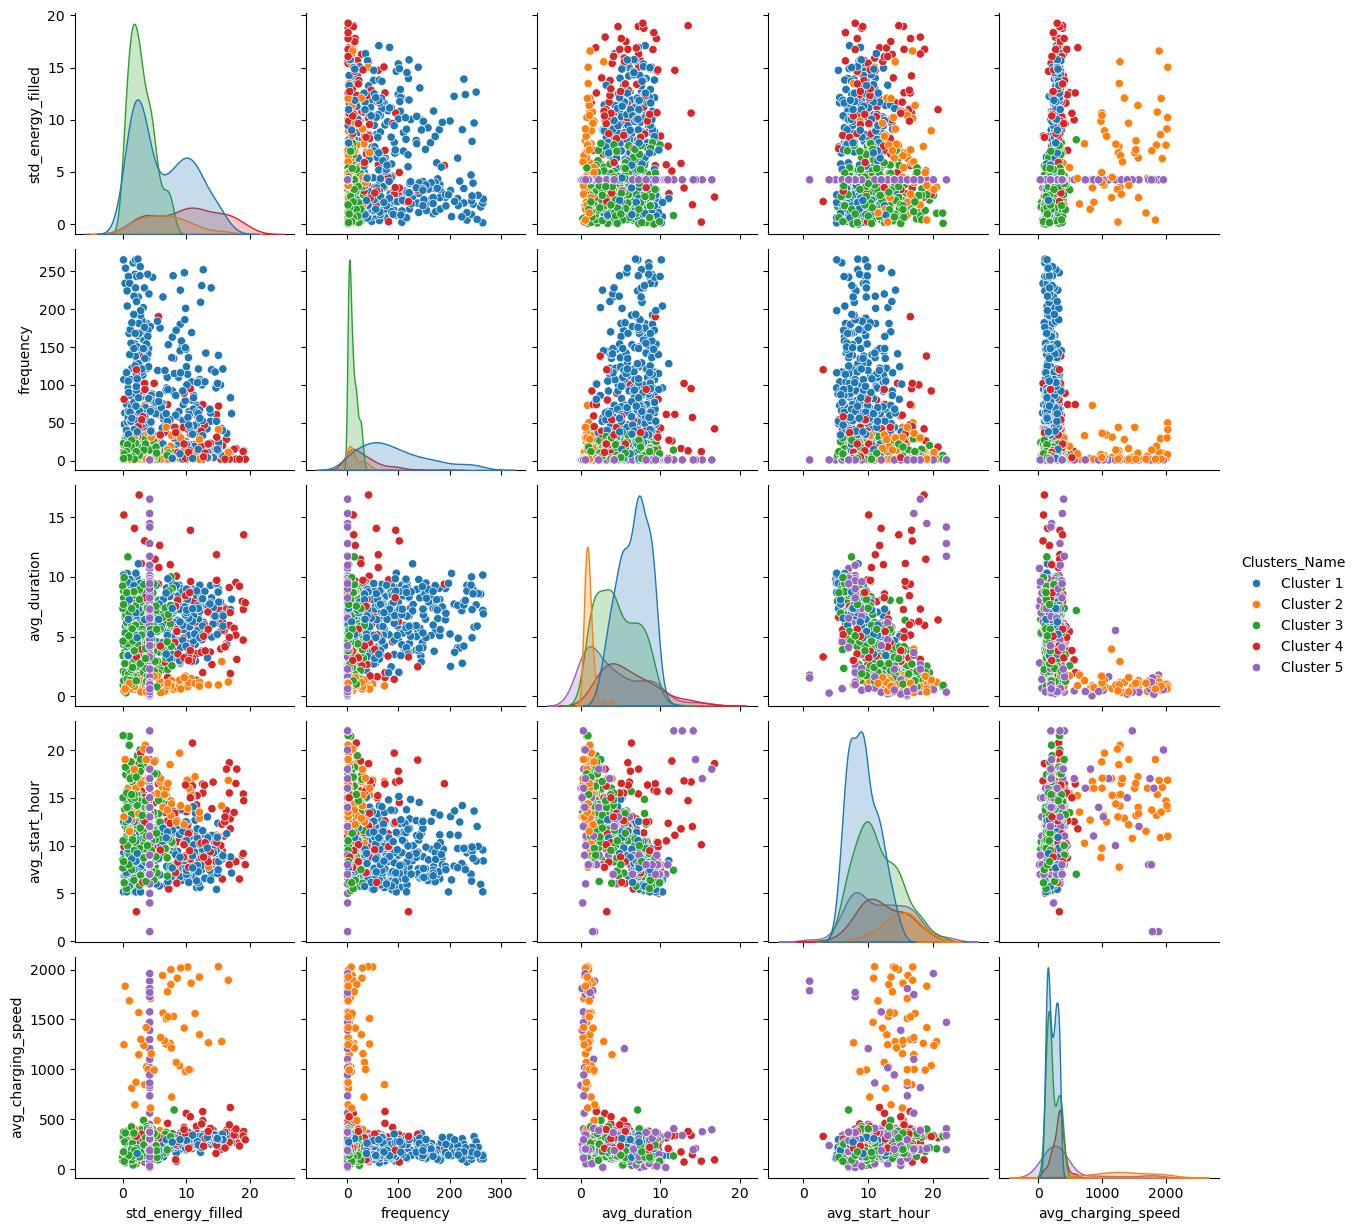

In [23]:
example_features = features_to_standardize

hue_order = sorted(user_profiles['Clusters_Name'].unique())
sns.pairplot(
    user_profiles[example_features + ['Clusters_Name']], 
    diag_kind='kde', 
    hue='Clusters_Name', 
    hue_order=hue_order,
    
)
plt.show()

**maybe noch bezüglich weekend session schauen sonst unnötiges feature**

* Cluster 1: Loyal everyday users
  * charge frequently with a medium session duration
  * medium charging speed with moderate energy variability
  * routine behavior due to typical early start hour
  * **=> stable, highly regular customers with plannable & predictable charging patterns; ideal for tarifs, loyalty programs &  reliable forecasting**

* Cluster 2: Fast Cahrging Specialists
  * very high charging speed
  * very short sessions with low frequency
  * late strt hours
  * **=> mobile, time-sensitive users; critical for HPC utilization, througput optimization, and cost recovery of fast-charging assets**

* Cluster 3: Light infrequent users
  * low frequency  and moderate session duration
  * low energy variability and standard charging speed
  * mid-day starrt hour
  * **=> occasional users with low dependency on charging; suited for Pay-per-use models and not for complex pricing structures or programs**

* Cluster 4: Heavy flexible chargers
  * moderate frequency combined with long sessions
  * high std_energy & charging speed shows big dips in energy demand (maybe due to variety of driving profiles)
  * flexible start times suggests adaptable charging windows
  * **=> high-demand yet flexible users; suited for dynamic pricing and load-shifting

* Cluster 5: New or one-off users
  * single charging event only as frequency = 1
  * medium session duration & above-average charging speed
  * no established temporal or behavioral pattern
  * **=> true one-time or newly onboarded users; suited for activation, education, and conversion campaigns**